<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
!pip install pandas
!pip install matplotlib
!pip install seaborn

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 150.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 165.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 89.6 MB/s eta 0:00:00


### Step 2: Load the Dataset


In [2]:
# Load the dataset from the given URL
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


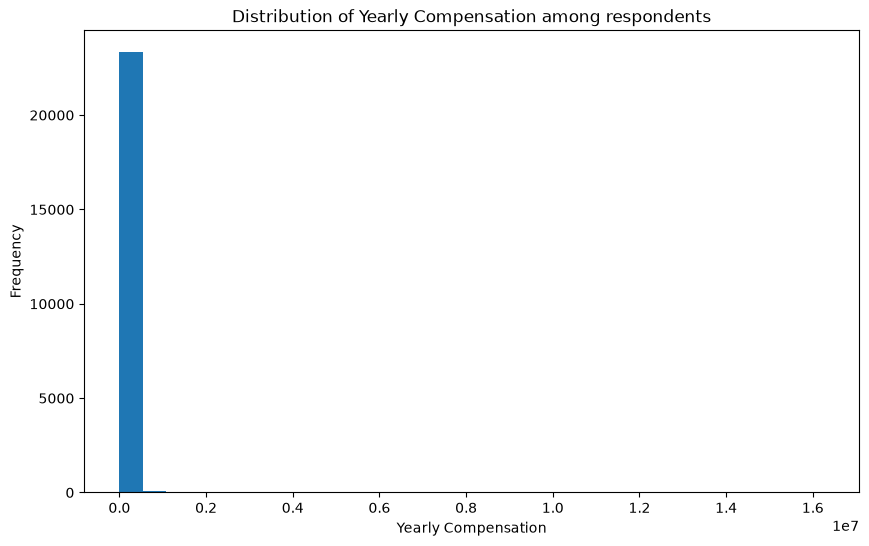

In [3]:
# Visualize the Distribution by Histogram for Yearly Conpensation among respondents
fig = plt.figure(figsize=(10, 6)) 

plt.hist(df['ConvertedCompYearly'].dropna(), bins=30)

plt.title('Distribution of Yearly Compensation among respondents')
plt.xlabel('Yearly Compensation')
plt.ylabel('Frequency')
plt.show()

# The Yearly Compensation distribution is strongly right-skewed (positively skewed).
# most respondents have compensation towards the lower end of the overall range, while a small
# number of respondents have extremely high compensation values, creating a long right tail.

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
# Calculate the median compensation for respondents
full_time = df[df['Employment'].str.contains('Employed, full-time', na=False)]

print(full_time['ConvertedCompYearly'].median())



67666.0


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.



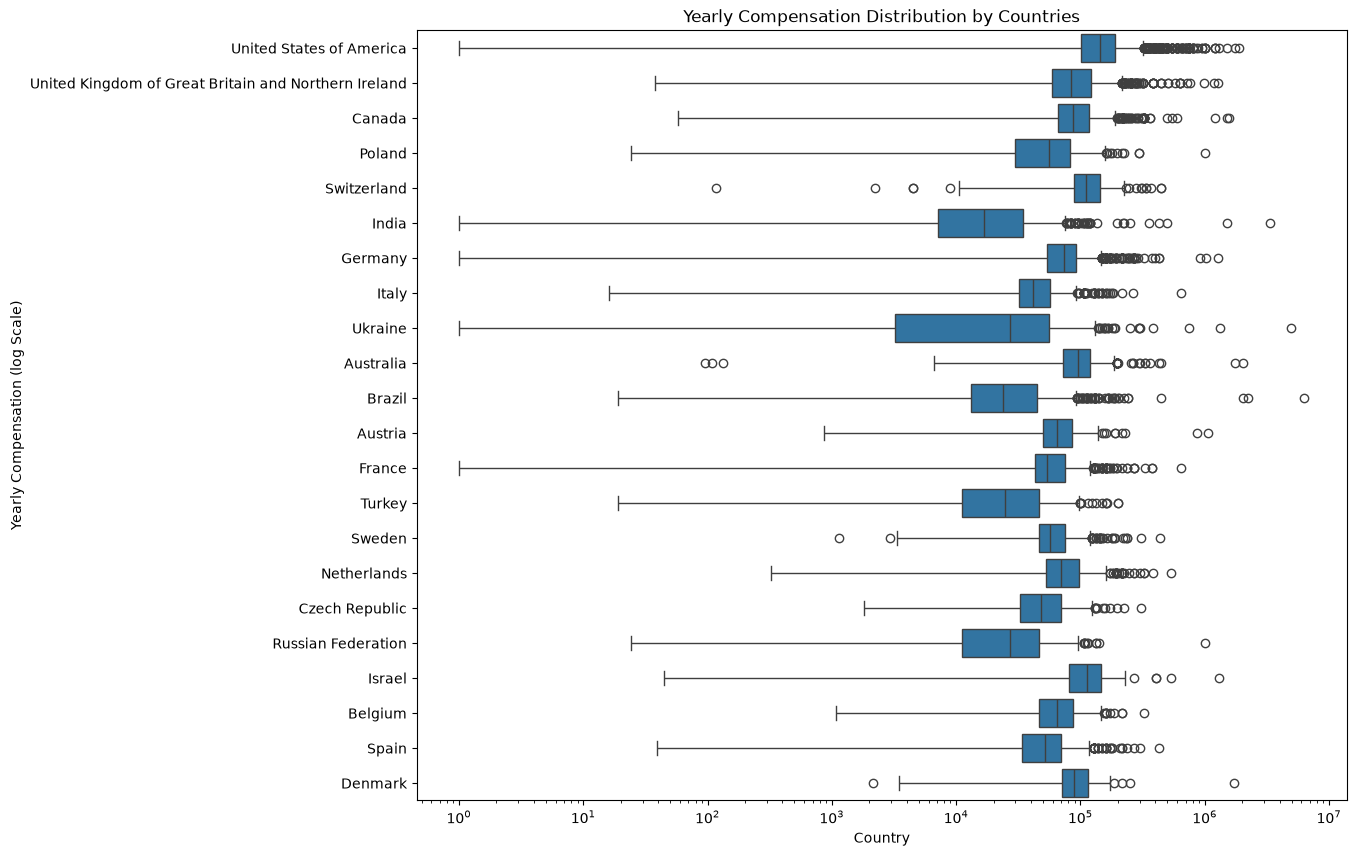

In [5]:
# Visualize the Compensation distribution for each countries
country_counts = df['Country'].value_counts()
country_counts.head(20)

valid_countries = country_counts[country_counts >= 500].index

df_country = df[df['Country'].isin(valid_countries)]

fig = plt.figure(figsize=(12, 10))

sns.boxplot(
    data=df_country,
    x='ConvertedCompYearly',
    y='Country'
)

plt.xscale('log')
plt.title('Yearly Compensation Distribution by Countries')
plt.xlabel('Country')
plt.ylabel('Yearly Compensation (log Scale)')
plt.show()

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


In [7]:
# Calculate Inter-Quartile Range
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)

IQR = Q3 - Q1

# Calculate Lower and Upper Bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[
    df['ConvertedCompYearly'].isna() |
 (
    (df['ConvertedCompYearly'] >=lower_bound) & 
    (df['ConvertedCompYearly'] <= upper_bound)
 )

]

print('Orignal rows:', df.shape)
print('Cleaned rows:', df_clean.shape)



Orignal rows: (65437, 114)
Cleaned rows: (64459, 114)


<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


In [14]:
# Calculate the Correlation 
correlation = df[['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']].corr()
correlation

,ConvertedCompYearly,WorkExp,JobSatPoints_1
ConvertedCompYearly,1.000000,0.154114,0.020306
WorkExp,0.154114,1.000000,-0.026490
JobSatPoints_1,0.020306,-0.026490,1.000000


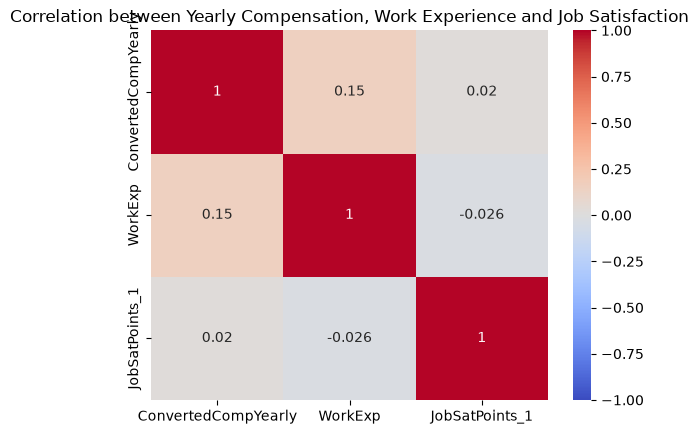

In [18]:
# Visualize the Correlation
sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)
plt.title('Correlation between Yearly Compensation, Work Experience and Job Satisfaction') 

plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


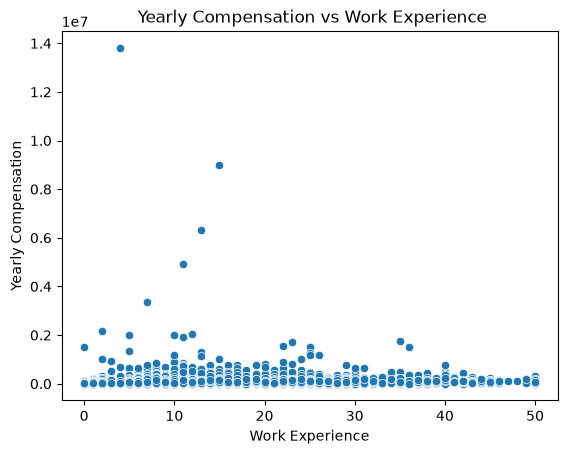

In [21]:
# Create Scatter Plot to examine correlation between ConvertedCompYearly and WorkExp


sns.scatterplot(
    data=df,
    x='WorkExp',
    y='ConvertedCompYearly',
)
plt.title(' Yearly Compensation vs Work Experience')
plt.ylabel('Yearly Compensation')
plt.xlabel('Work Experience')
plt.show()

# There is only a weak positive relationship between work experience and yearly compensation.

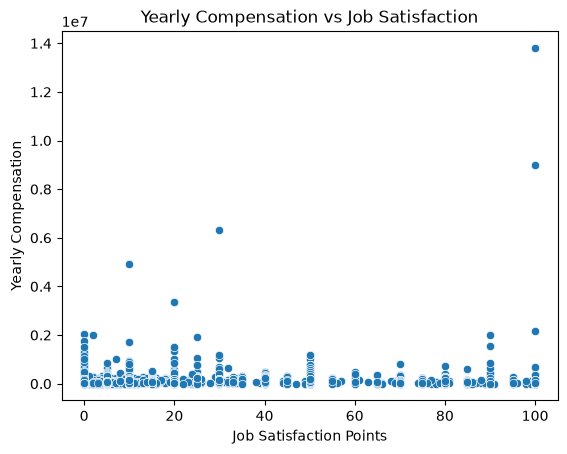

In [23]:
# Create a Scatter Plot to examine correlation between ConvertedCompYearly and JobSatPoints_1
sns.scatterplot(
    data=df,
    x='JobSatPoints_1',
    y='ConvertedCompYearly'
)
plt.title('Yearly Compensation vs Job Satisfaction')
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Yearly Compensation')
plt.show()

# The Scatter Plot shows almost no linear relationship between job satisfaction and yearly compensation .

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
